<a href="https://colab.research.google.com/github/RiteeshTM/Financial-Market-Trend-Risk-Analysis-Business-Analytics-Project-/blob/main/Reliance%20Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

In [2]:
data = yf.download("RELIANCE.NS", start="2018-01-01")

if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

data.tail()

/tmp/ipykernel_663/941683073.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("RELIANCE.NS", start="2018-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2026-03-09,1424.000000,1429.400024,1370.000000,1375.000000,24870822
2026-03-10,1408.800049,1431.500000,1400.599976,1430.599976,18071259
2026-03-11,1390.199951,1434.000000,1383.599976,1424.900024,21848087
2026-03-12,1392.199951,1410.900024,1381.099976,1390.000000,20939959
2026-03-13,1380.699951,1400.800049,1378.400024,1385.199951,17263343


In [3]:
data["simple_return"] = data["Close"].pct_change()

data["log_return"] = np.log(data["Close"] / data["Close"].shift(1))

data = data.dropna()
data

Price,Close,High,Low,Open,Volume,simple_return,log_return
Date,,,,,,,
2018-01-02,402.483215,406.193768,400.384994,403.300424,9499419,0.001539,0.001538
2018-01-03,404.095551,409.042944,403.322514,408.601196,13507800,0.004006,0.003998
2018-01-04,406.525085,407.187693,404.493122,405.575361,9008932,0.006012,0.005994
2018-01-05,407.828186,409.440517,406.503001,407.187694,7441284,0.003205,0.003200
2018-01-08,410.169312,411.251551,407.938575,409.087072,8827020,0.005740,0.005724
...,...,...,...,...,...,...,...
2026-03-09,1424.000000,1429.400024,1370.000000,1375.000000,24870822,0.013667,0.013575
2026-03-10,1408.800049,1431.500000,1400.599976,1430.599976,18071259,-0.010674,-0.010732
2026-03-11,1390.199951,1434.000000,1383.599976,1424.900024,21848087,-0.013203,-0.013291


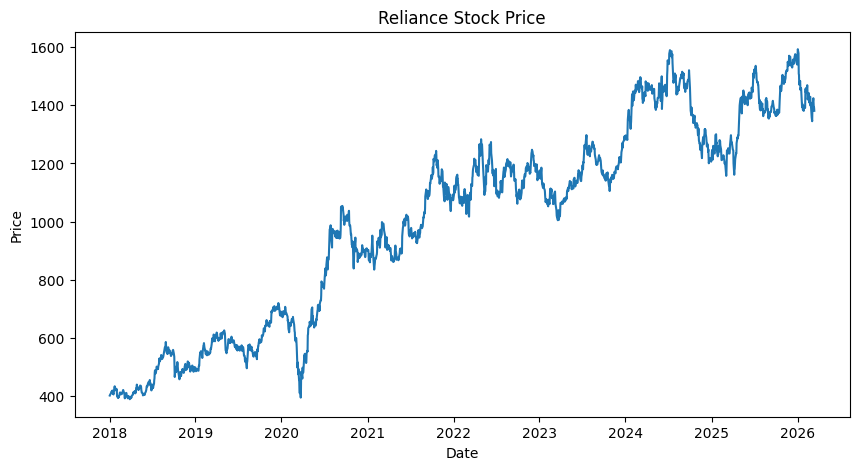

In [4]:
plt.figure(figsize=(10,5))
plt.plot(data.index, data["Close"])
plt.title("Reliance Stock Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

## Volatility Analysis

In [5]:
daily_volatility = data["log_return"].std()
annual_volatility = daily_volatility * np.sqrt(252)

print("Daily Volatility:", daily_volatility)
print("Annual Volatility:", annual_volatility)

Daily Volatility: 0.017485001509694755
Annual Volatility: 0.2775657940094475


## Sharpe Ratio

In [6]:
annual_return = data["log_return"].mean() * 252

risk_free_rate = 0.07  # Approx Indian risk-free rate

sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility

print("Annual Return:", annual_return)
print("Sharpe Ratio:", sharpe_ratio)

Annual Return: 0.1535930827417075
Sharpe Ratio: 0.301164929345949


## Beta Calculation (Market Risk)

In [7]:
# Download NIFTY data
market = yf.download("^NSEI", start="2018-01-01")

if isinstance(market.columns, pd.MultiIndex):
    market.columns = market.columns.get_level_values(0)

data.index = data.index.tz_localize(None)
market.index = market.index.tz_localize(None)

market["market_return"] = np.log(
    market["Close"] / market["Close"].shift(1)
)

df = pd.concat(
    [data["log_return"], market["market_return"]],
    axis=1
).dropna()

# Regression
X = sm.add_constant(df["market_return"])
y = df["log_return"]

model = sm.OLS(y, X).fit()

beta = model.params[1]

print("Beta:", beta)

/tmp/ipykernel_663/2706225358.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  market = yf.download("^NSEI", start="2018-01-01")
[*********************100%***********************]  1 of 1 completed

Beta: 1.1101513164751835



/tmp/ipykernel_663/2706225358.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta = model.params[1]


##  Value at Risk (VaR)

In [8]:
VaR_95 = np.percentile(data["log_return"], 5)

print("95% Value at Risk:", VaR_95)

95% Value at Risk: -0.02355478902866063


## Stationarity Test (ADF)

In [9]:
result = adfuller(data["log_return"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -13.489625561848856
p-value: 3.1246386561490577e-25


## ARIMA Model

In [10]:
model = ARIMA(data["log_return"], order=(1,0,1))
model_fit = model.fit()

print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             log_return   No. Observations:                 2025
Model:                 ARIMA(1, 0, 1)   Log Likelihood                5321.841
Date:                Sat, 14 Mar 2026   AIC                         -10635.682
Time:                        10:36:34   BIC                         -10613.229
Sample:                             0   HQIC                        -10627.443
                               - 2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0006      0.000      1.554      0.120      -0.000       0.001
ar.L1         -0.6193      0.269     -2.301      0.021      -1.147      -0.092
ma.L1          0.5976      0.273      2.188      0.0

## Forecast Future Returns

In [11]:
forecast = model_fit.forecast(steps=5)

print("Next 5 day forecast:")
print(forecast)

Next 5 day forecast:
2025    0.000815
2026    0.000479
2027    0.000687
2028    0.000558
2029    0.000638
Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


## Return Distribution

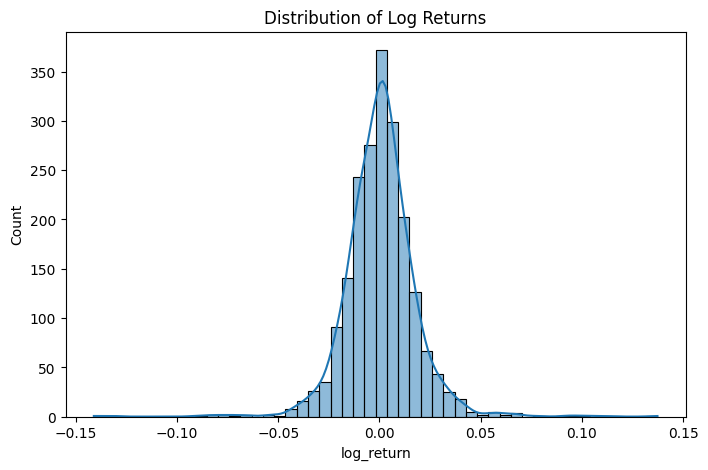

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(data["log_return"], bins=50, kde=True)
plt.title("Distribution of Log Returns")
plt.show()

## Performance Analysis using Pyfolio

In this section we analyze the performance of Reliance Industries stock using the Pyfolio library.

We compare the performance of Reliance Industries against the NIFTY 50 index.

In [13]:
!pip install pyfolio-reloaded

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 34.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 106.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 56.9 MB/s eta 0:00:00
  Created wheel for peewee: filename=peewee-3.17.3-py3-none-any.whl size=138489 sha256=124b8b8413b87c18ae2cef46796afeaae15d3c47ef7d9684b97b04ba224c1d85
  Stored in directory: /root/.cache/pip/wheels/39/c7/dd/909d267742f7fbb941ff081dacd661f622a0b4eb38f667b84b
Successfully built peewee
  Attempting uninstall: peewee
    Found existing installation: peewee 4.0.1
    Uninstalling peewee-4.0.1:
      Successfully uninstalled peewee-4.0.1


In [13]:
import pyfolio as pf
import pandas as pd
import numpy as np
import yfinance as yf

/usr/local/lib/python3.12/dist-packages/pyfolio/pos.py:25: UserWarning: Module "zipline.assets" not found; multipliers will not be applied to position notionals.
  warnings.warn(


### Download Benchmark Data (NIFTY 50)

To evaluate the performance of the stock relative to the market, we use the NIFTY 50 index as a benchmark.

In [14]:
market = yf.download("^NSEI", start="2018-01-01")

# fix multiindex if present
if isinstance(market.columns, pd.MultiIndex):
    market.columns = market.columns.get_level_values(0)

market.tail()

/tmp/ipykernel_663/1969775549.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  market = yf.download("^NSEI", start="2018-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2026-03-09,24028.050781,24078.150391,23697.800781,23868.050781,526900
2026-03-10,24261.599609,24303.800781,24079.949219,24280.800781,444300
2026-03-11,23866.849609,24299.000000,23834.300781,24231.849609,407400
2026-03-12,23639.150391,23833.150391,23556.300781,23674.849609,501000
2026-03-13,23151.099609,23492.400391,23112.000000,23462.500000,0


### Compute Benchmark Returns

We compute log returns for the benchmark index to ensure consistency with the stock returns used earlier.

In [15]:
market["market_return"] = np.log(
    market["Close"] / market["Close"].shift(1)
)

benchmark_returns = market["market_return"].dropna()

benchmark_returns.head()

,market_return
Date,
2018-01-03,0.000096
2018-01-04,0.005881
2018-01-05,0.005132
2018-01-08,0.006114
2018-01-09,0.001261


### Prepare Stock Returns

Pyfolio requires a clean return series indexed by datetime.

We remove timezone information and ensure the data is aligned properly.

In [16]:
returns = data["log_return"]

# remove timezone if present
returns.index = returns.index.tz_localize(None)
benchmark_returns.index = benchmark_returns.index.tz_localize(None)

### Generate Pyfolio Performance Report

The Pyfolio tear sheet provides a comprehensive summary of portfolio performance including:

- cumulative returns
- drawdown periods
- rolling Sharpe ratio
- volatility analysis
- return distribution

/usr/local/lib/python3.12/dist-packages/pyfolio/plotting.py:670: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '12.135%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  perf_stats.loc[stat, column] = str(np.round(value * 100, 3)) + "%"


Start date,2018-01-03
End date,2026-03-13
Total months,96
,Backtest
Annual return,12.135%
Cumulative returns,150.444%
Annual volatility,27.791%
Sharpe ratio,0.55
Calmar ratio,0.26
Stability,0.82
Max drawdown,-47.467%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,47.47,2019-12-19,2020-03-23,2020-06-19,132
1,28.12,2024-07-08,2025-03-04,NaT,NaN
2,23.70,2022-04-28,2023-03-20,2024-01-11,446
3,22.80,2018-08-28,2018-10-25,2019-03-19,146
4,22.37,2020-09-16,2021-01-29,2021-09-06,254


/usr/local/lib/python3.12/dist-packages/pyfolio/plotting.py:1407: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Daily", "Weekly", "Monthly"])


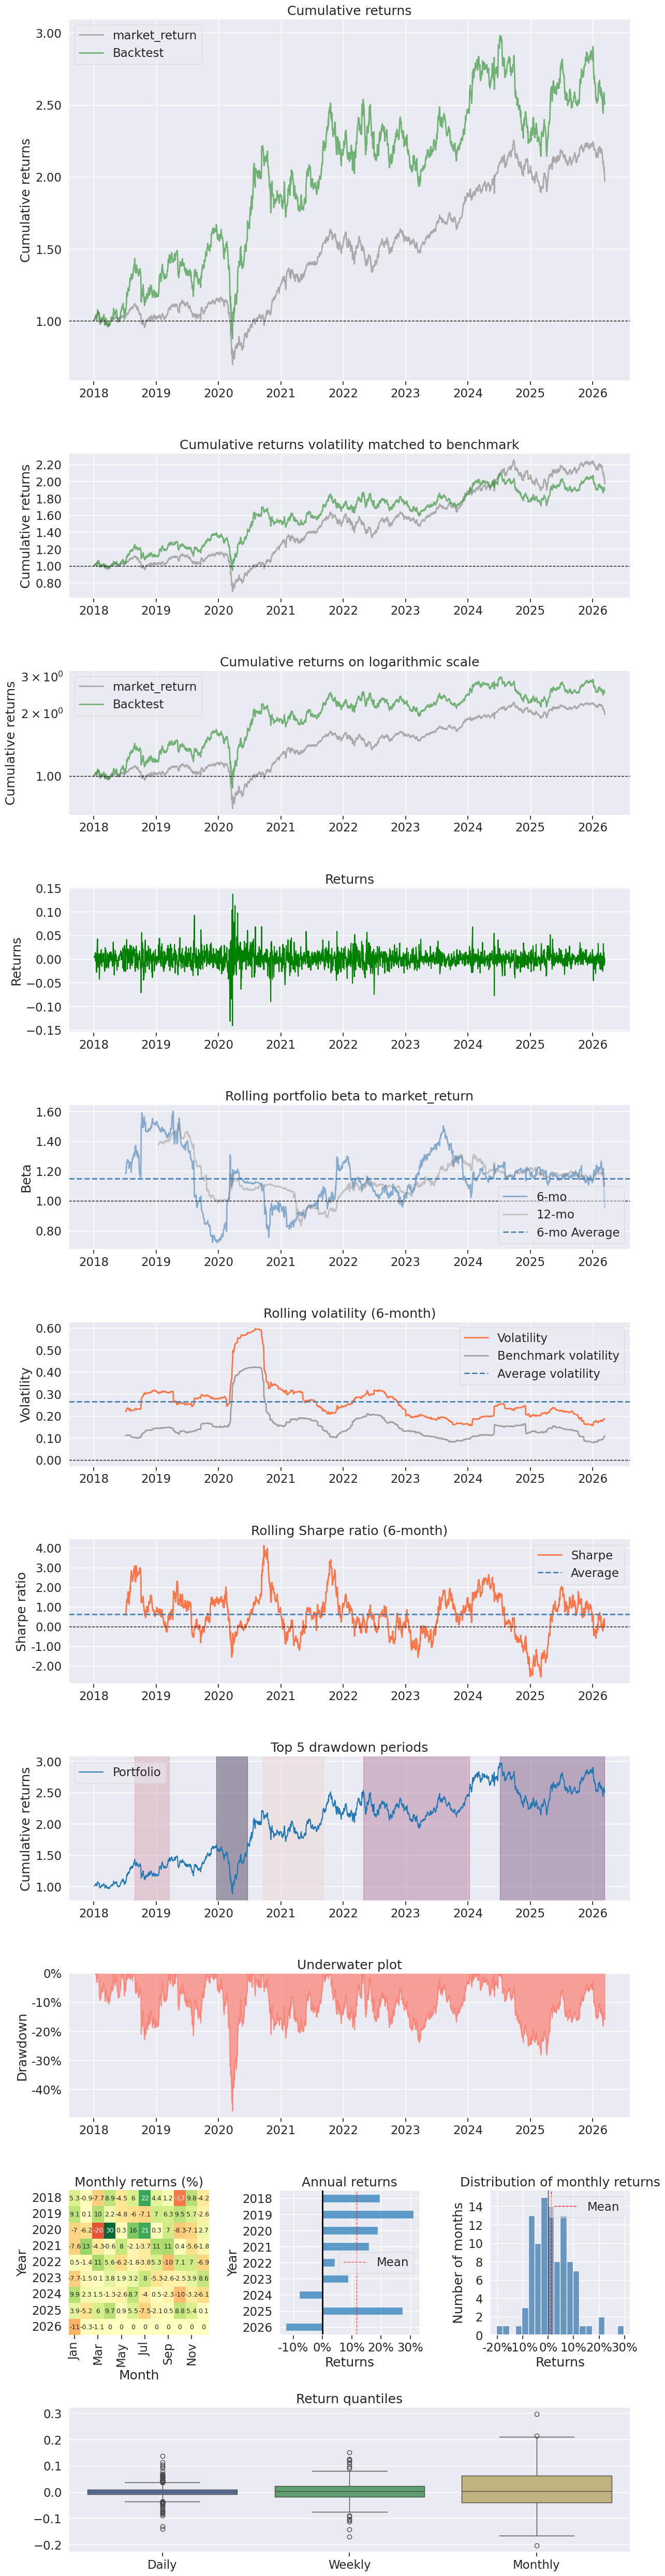

In [17]:
pf.create_returns_tear_sheet(
    returns,
    benchmark_rets=benchmark_returns
)

### Rolling Volatility

Rolling volatility helps visualize how risk evolves over time.

<Axes: title={'center': 'Rolling volatility (6-month)'}, ylabel='Volatility'>

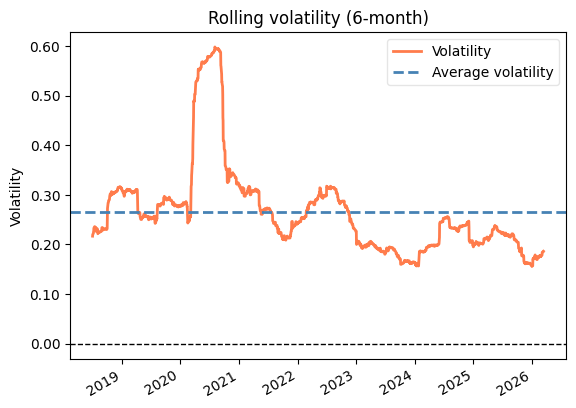

In [18]:
pf.plotting.plot_rolling_volatility(returns)

### Rolling Sharpe Ratio

This plot shows how the risk-adjusted return changes through time.

<Axes: title={'center': 'Rolling Sharpe ratio (6-month)'}, ylabel='Sharpe ratio'>

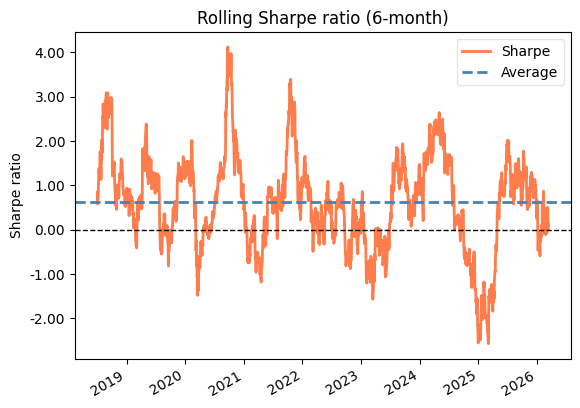

In [19]:
pf.plotting.plot_rolling_sharpe(returns)

### Drawdown Analysis

Drawdown represents the decline from a historical peak.

This helps identify periods of large losses.

<Axes: title={'center': 'Top 10 drawdown periods'}, ylabel='Cumulative returns'>

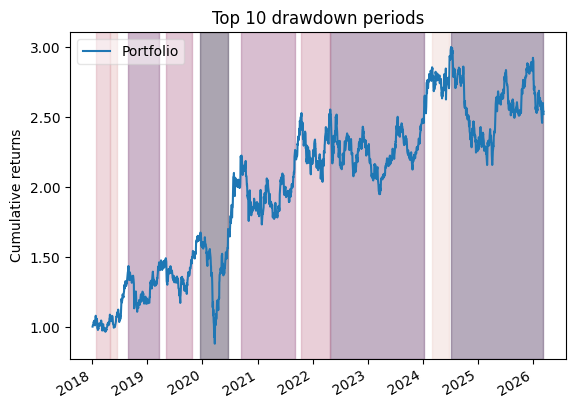

In [20]:
pf.plotting.plot_drawdown_periods(returns)

## Rolling Metrics

Text(0.5, 1.0, '30-Day Rolling Volatility')

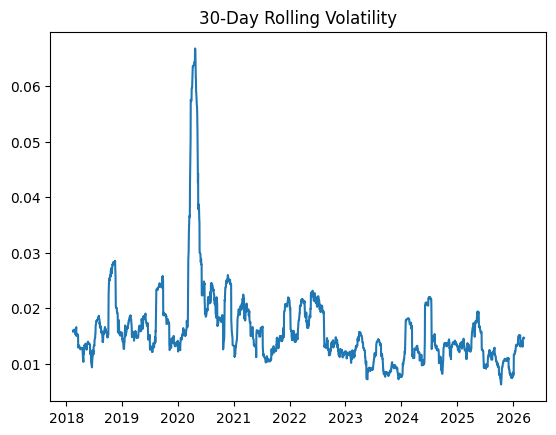

In [21]:
data["rolling_vol"] = data["log_return"].rolling(30).std()

plt.plot(data["rolling_vol"])
plt.title("30-Day Rolling Volatility")

## Maximum Drawdown

Text(0.5, 1.0, 'Maximum Drawdown')

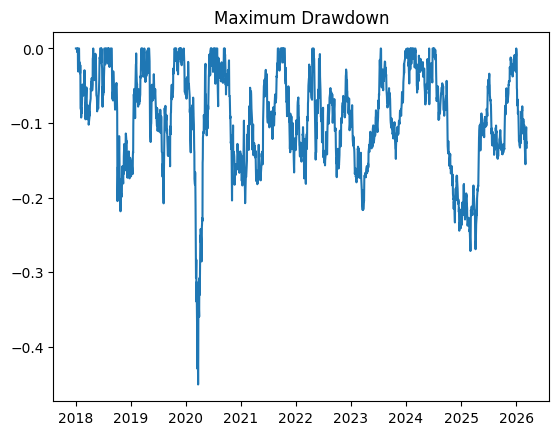

In [22]:
cum_returns = (1 + data["simple_return"]).cumprod()
rolling_max = cum_returns.cummax()
drawdown = cum_returns / rolling_max - 1

plt.plot(drawdown)
plt.title("Maximum Drawdown")

## Cumulative Return

Text(0.5, 1.0, 'Cumulative Returns')

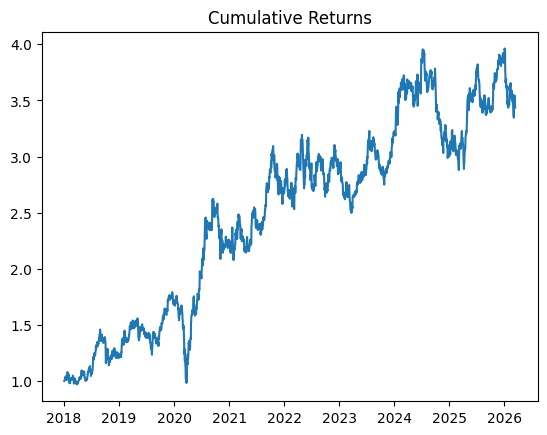

In [23]:
cum_returns = (1 + data["simple_return"]).cumprod()

plt.plot(cum_returns)
plt.title("Cumulative Returns")